# The ENG corridor fiscal case, step by step

**MBTA bus routes 23, 28 and 66 — MIT Policy Hackathon 2025, second place**

This notebook walks through the cost-benefit model behind the memo's headline
claims: a $6.5 million quick-build bus-priority package on three routes, paying
back in under two years and returning 1.23 million rider-hours a year.

It needs no raw data. Everything comes from the published route metrics in
`data/processed/` plus the assumptions in `eng_corridors.config`.

The structure follows the model's three benefit buckets, which are kept separate
because they are not the same kind of money:

1. **Operating savings** — cash the MBTA stops spending
2. **Rail fare revenue** — cash the MBTA starts receiving
3. **Rider time** — economic benefit that never touches the agency's books

Payback and NPV use buckets 1 and 2 only.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import pandas as pd
import numpy as np

from eng_corridors.config import DEFAULT_ASSUMPTIONS, FiscalAssumptions, PROCESSED
from eng_corridors import fiscal, viz

pd.set_option("display.float_format", "{:,.2f}".format)
viz.use_house_style()

## The three routes

Everything downstream rests on this table. `tdi` and `equity_volume_score` are
what selected these routes out of the whole network; `rev_hours_per_weekday` and
`avg_weekday_boardings` are what drive the money.

In [2]:
routes = pd.read_csv(PROCESSED / "eng_corridor_metrics.csv")
routes

,route_id,corridor_role,tdi,avg_weekday_boardings,equity_volume_score,avg_peak_runtime_min,avg_trip_runtime_min,avg_trips_per_weekday,rev_hours_per_weekday,otp_peak,otp_offpeak,share_near_rail,fare_free_2025
0,28,Blue Hill Ave / Warren St spine,3.00,"12,394.40","37,147.00",40.38,41.10,192.54,131.89,0.76,0.78,0.43,True
1,23,Blue Hill Ave / Warren St spine,2.98,"11,273.40","33,608.80",35.39,36.04,205.53,123.47,0.78,0.80,0.50,True
2,66,Allston-Brookline-Roxbury crosstown,2.48,"11,348.80","28,156.50",48.66,48.94,208.75,170.29,0.72,0.71,0.59,False


A TDI of 3.00 means Route 28's catchment is three times as
transit-dependent as the MBTA service area average, across no-vehicle,
low-income, non-white and transit-commute shares.

These three routes rank **first, second and third on equity volume out of the
entire MBTA bus network** — and they are also among the slowest. That
coincidence is the whole argument.

## Assumptions

Every number the model assumes rather than measures, in one frozen dataclass.
Nothing is hard-coded downstream, so any of these can be challenged and the
whole case re-run.

In [3]:
for key, value in DEFAULT_ASSUMPTIONS.__dict__.items():
    print(f"{key:<32} {value}")

speed_improvement                0.2
cost_per_bus_revenue_hour        297.0
weekdays_per_year                250
reinvestment_share               0.5
capital_cost_per_mile_musd       0.5
corridor_miles                   10.0
soft_cost_multiplier             1.3
ridership_uplift                 0.15
share_near_rail                  0.51
new_transfer_share               0.5
avg_rail_fare                    1.7
discount_rate                    0.04
horizon_years                    10
value_of_time_low                10.0
value_of_time_high               20.0


## Capital cost

Roughly 6 miles of overlapping segments on the 23/28 spine plus 4 miles of
high-delay segments on route 66. Quick-build — paint, posts and signal software
— at the $0.5M/mile benchmark from comparable projects, plus 30% for signals,
TSP hardware, stop works and design.

In [4]:
capex = fiscal.capital_cost()
print(f"{DEFAULT_ASSUMPTIONS.corridor_miles:.0f} mi "
      f"x ${DEFAULT_ASSUMPTIONS.capital_cost_per_mile_musd}M/mi "
      f"x {DEFAULT_ASSUMPTIONS.soft_cost_multiplier} = ${capex/1e6:.2f}M")

10 mi x $0.5M/mi x 1.3 = $6.50M


## Bucket 1 — Operating savings

The sturdiest part of the case, because it depends only on vehicle hours and not
at all on how many people ride.

Hold the timetable fixed. A 20% runtime cut means 20% fewer bus-hours are needed
to deliver the identical service.

In [5]:
ops = fiscal.operating_savings(routes)
ops

,route_id,rev_hours_per_weekday,bus_hours_saved_per_weekday,gross_savings_per_weekday,gross_savings_per_year,net_savings_per_year
0,28,131.89,26.38,"7,834.27","1,958,566.50","979,283.25"
1,23,123.47,24.69,"7,334.12","1,833,529.50","916,764.75"
2,66,170.29,34.06,"10,115.23","2,528,806.50","1,264,403.25"


In [6]:
print(f"Bus-hours freed per weekday   {ops['bus_hours_saved_per_weekday'].sum():,.1f}")
print(f"Gross savings per year        ${ops['gross_savings_per_year'].sum()/1e6:,.2f}M")
print(f"Net after 50% reinvestment    ${ops['net_savings_per_year'].sum()/1e6:,.2f}M")

Bus-hours freed per weekday   85.1
Gross savings per year        $6.32M
Net after 50% reinvestment    $3.16M


Half the freed hours are assumed reinvested into frequency, recovery
time and extending priority into evenings and weekends. That is a **policy
choice, not a measurement**, and it halves the headline number. We made it
because a proposal that banks 100% of savings is not credible to an agency under
service pressure — and because reinvestment is what riders actually feel.

## Bucket 2 — Rail fare revenue

Three assumptions in series. This is the weakest link in the analysis, which is
why it is also the smallest bucket.

Faster buses lift boardings 15% (Columbus Avenue and comparable pilots) → 51% of
those extra trips start or end within 400 m of rail → half of those are
genuinely new rail transfers. An effective conversion of about 25%.

In [7]:
rail = fiscal.rail_revenue(routes)
for key, value in rail.items():
    print(f"{key:<34} {value:>14,.2f}")

baseline_weekday_boardings              35,016.60
extra_bus_trips_per_weekday              5,252.49
effective_conversion_rate                    0.26
new_rail_trips_per_weekday               1,339.38
rail_revenue_per_weekday                 2,276.95
rail_revenue_per_year                  569,238.60


The case does not depend on this. Set rail revenue to zero and
payback is still 2.1 years.

In [8]:
no_rail = fiscal.fiscal_summary(routes, FiscalAssumptions(ridership_uplift=1e-9))
print(f"Payback with no rail benefit at all: {no_rail.payback_years:.1f} years")

Payback with no rail benefit at all: 2.1 years


## Bucket 3 — Rider time

Not agency money. Reported separately and excluded from payback, because mixing
societal benefit into a payback calculation is how cost-benefit analyses get
dismissed by the people who have to sign off on them.

In [9]:
time = fiscal.rider_time_savings(routes)
time

,route_id,avg_trip_runtime_min,avg_weekday_boardings,minutes_saved_per_trip,rider_hours_per_weekday,rider_hours_per_year,hours_saved_per_year_daily_commuter
0,28,41.10,"12,394.40",8.22,"1,698.03","424,508.20",68.50
1,23,36.04,"11,273.40",7.21,"1,354.31","338,577.78",60.07
2,66,48.94,"11,348.80",9.79,"1,851.37","462,841.89",81.57


In [10]:
total_hours = time["rider_hours_per_year"].sum()
print(f"Rider-hours per weekday   {time['rider_hours_per_weekday'].sum():,.0f}")
print(f"Rider-hours per year      {total_hours/1e6:,.2f}M")
print(f"At $10/hour               ${total_hours*10/1e6:,.1f}M")
print(f"At $20/hour               ${total_hours*20/1e6:,.1f}M")

Rider-hours per weekday   4,904
Rider-hours per year      1.23M
At $10/hour               $12.3M
At $20/hour               $24.5M


For someone riding both ways, five days a week, that is **60 to 82
hours a year** — one and a half to two working weeks returned to them.

One caveat that matters: each boarding is treated as one one-way trip saving the
full proportional runtime. A rider not travelling the whole route saves
proportionally less, so this is an **upper bound on the typical journey**. That
is why it is reported as a $10–20 band rather than a point estimate.

## Putting it together

In [11]:
summary = fiscal.fiscal_summary(routes)
print(summary)

Capital cost                  $    6.50M
Bus-hours saved / weekday          85.1
Gross O&M savings / year      $    6.32M
Net O&M savings / year        $    3.16M
New rail revenue / year       $    0.57M
Direct benefit / year         $    3.73M
Payback                             1.7 years
10-year NPV                   $    23.8M
Rider-hours saved / year           1.23M
Rider time value / year       $    12.3M - $24.5M


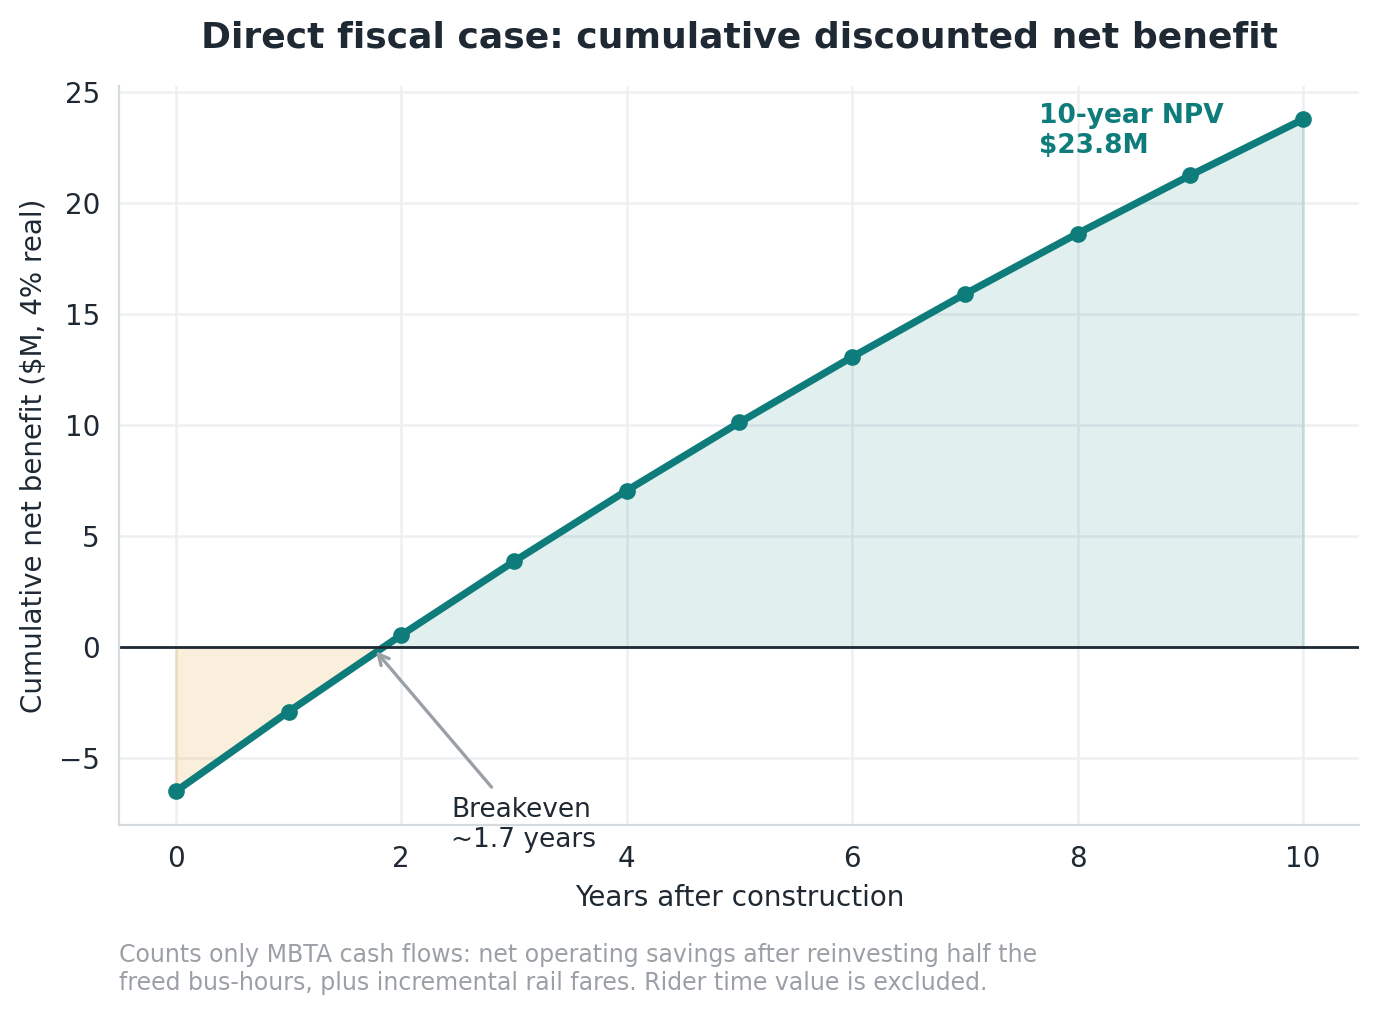

In [12]:
fig_dir = Path.cwd().parent / "figures"
viz.plot_payback(routes, fig_dir)
from IPython.display import Image
Image(str(fig_dir / "fig04_payback.png"))

## Does it survive pessimism?

The interesting question is not what the model says at the central case. It is
how far you have to push the assumptions before the recommendation stops
holding.

In [13]:
sweep = fiscal.sensitivity(routes, "speed_improvement", np.arange(0.05, 0.31, 0.05))
out = sweep.copy()
for col in ["net_om_savings_per_year", "rail_revenue_per_year",
            "direct_benefit_per_year", "npv_10yr"]:
    out[col] = out[col] / 1e6
out["rider_hours_per_year"] = out["rider_hours_per_year"] / 1e6
out

,speed_improvement,net_om_savings_per_year,rail_revenue_per_year,direct_benefit_per_year,payback_years,npv_10yr,rider_hours_per_year
0,0.05,0.79,0.57,1.36,4.78,4.53,0.31
1,0.10,1.58,0.57,2.15,3.02,10.93,0.61
2,0.15,2.37,0.57,2.94,2.21,17.34,0.92
3,0.20,3.16,0.57,3.73,1.74,23.75,1.23
4,0.25,3.95,0.57,4.52,1.44,30.16,1.53
5,0.30,4.74,0.57,5.31,1.22,36.57,1.84


In [14]:
# How weak can the speed gain be before payback exceeds five years?
fine = fiscal.sensitivity(routes, "speed_improvement", np.arange(0.03, 0.21, 0.005))
threshold = fine[fine["payback_years"] <= 5]["speed_improvement"].min()
print(f"Payback stays under 5 years down to a {threshold:.1%} runtime reduction.")
print("Documented range for comparable bus-priority projects: 10-25%.")

Payback stays under 5 years down to a 5.0% runtime reduction.
Documented range for comparable bus-priority projects: 10-25%.


Now a deliberately hostile scenario: halve the speed gain, cut the
ridership response to a third, raise the discount rate to 8%, and use the bottom
of the NTD operating-cost range.

In [15]:
pessimistic = FiscalAssumptions(
    speed_improvement=0.10,
    ridership_uplift=0.05,
    discount_rate=0.08,
    cost_per_bus_revenue_hour=250.0,
)
print(fiscal.fiscal_summary(routes, pessimistic))

Capital cost                  $    6.50M
Bus-hours saved / weekday          42.6
Gross O&M savings / year      $    2.66M
Net O&M savings / year        $    1.33M
New rail revenue / year       $    0.19M
Direct benefit / year         $    1.52M
Payback                             4.3 years
10-year NPV                   $     3.7M
Rider-hours saved / year           0.61M
Rider time value / year       $     6.1M - $12.3M


Still under five years, still a positive NPV. This scenario is
asserted in `tests/test_fiscal.py` so it cannot silently stop being true.

## What would actually change the answer

Not the speed assumption — the model is robust there. The things that would
matter:

- **Capital cost being badly wrong.** At 3x the estimate, payback goes to about
  five years. Quick-build costs are well benchmarked, but utility relocation or
  significant civil work would break this.
- **The reinvestment share.** At 100% reinvestment there are no banked savings
  and only the rail revenue repays the capital. That is a legitimate policy
  position, and the model should be able to say so honestly.
- **Induced demand on the cost side.** If ridership really rises 15%, crowding
  may require more service, which is a cost the model does not carry.

All three are in `docs/reproducibility.md` under modelling limitations.

In [16]:
for share in [0.0, 0.25, 0.50, 0.75, 1.0]:
    s = fiscal.fiscal_summary(routes, FiscalAssumptions(reinvestment_share=share))
    payback = f"{s.payback_years:.1f} yr" if s.payback_years < 50 else "never"
    print(f"reinvest {share:>4.0%}   benefit ${s.direct_benefit_per_year/1e6:.2f}M/yr"
          f"   payback {payback:>7}   NPV ${s.npv_10yr/1e6:>6.1f}M")

reinvest   0%   benefit $6.89M/yr   payback  0.9 yr   NPV $  49.4M
reinvest  25%   benefit $5.31M/yr   payback  1.2 yr   NPV $  36.6M
reinvest  50%   benefit $3.73M/yr   payback  1.7 yr   NPV $  23.8M
reinvest  75%   benefit $2.15M/yr   payback  3.0 yr   NPV $  10.9M
reinvest 100%   benefit $0.57M/yr   payback 11.4 yr   NPV $  -1.9M


---

Full methodology in [`docs/methodology.md`](../docs/methodology.md). Known
discrepancies and limitations in
[`docs/reproducibility.md`](../docs/reproducibility.md).